In [1]:
import os

In [2]:
%pwd

'c:\\Users\\Hp\\Desktop\\cifar10-image-classificatio\\research'

In [3]:
os.chdir("../")

In [4]:
%pwd

'c:\\Users\\Hp\\Desktop\\cifar10-image-classificatio'

In [5]:
from pathlib import Path
from dataclasses import dataclass
import os
import numpy as np
from tensorflow.keras.datasets import cifar10
import yaml

In [6]:
import ssl
ssl._create_default_https_context = ssl._create_unverified_context

In [7]:


CONFIG_FILE_PATH = Path(r"C:\Users\Hp\Desktop\cifar10-image-classificatio\config\config.yaml")

with open(CONFIG_FILE_PATH, "r") as yaml_file:
    config = yaml.safe_load(yaml_file)

config

{'artifacts_root': 'artifacts',
 'data_ingestion': {'root_dir': 'artifacts/data_ingestion'},
 'prepare_model': {'root_dir': 'artifacts/prepare_model',
  'model_path': 'artifacts/prepare_model/model.keras'},
 'training': {'root_dir': 'artifacts/training',
  'trained_model_path': 'artifacts/training/model.h5'}}

config_entity

In [8]:
from pathlib import Path
from dataclasses import dataclass

@dataclass
class DataIngestionConfig:
    root_dir: Path

In [9]:
%pwd

'c:\\Users\\Hp\\Desktop\\cifar10-image-classificatio'

In [10]:
from src.cnnClassifier.constants import *

In [11]:
from src.cnnClassifier.utils.common import read_yaml, create_directories

configuration

In [12]:
class ConfigurationManager:

    def __init__(self, config_filepath=CONFIG_FILE_PATH):

        with open(config_filepath, "r") as yaml_file:
            self.config = yaml.safe_load(yaml_file)

        create_directories([self.config["artifacts_root"]])

    def get_data_ingestion_config(self):

        config = self.config["data_ingestion"]

        create_directories([config["root_dir"]])

        data_ingestion_config = DataIngestionConfig(
            root_dir=Path(config["root_dir"])
        )

        return data_ingestion_config

In [13]:
class DataIngestion:

    def __init__(self, config):
        self.config = config

    def download_data(self):

        print("Downloading CIFAR-10 dataset...")

        (X_train, y_train), (X_test, y_test) = cifar10.load_data()

        # folder create
        os.makedirs(self.config.root_dir, exist_ok=True)

        # save as .npy files
        np.save(self.config.root_dir / "X_train.npy", X_train)
        np.save(self.config.root_dir / "y_train.npy", y_train)
        np.save(self.config.root_dir / "X_test.npy", X_test)
        np.save(self.config.root_dir / "y_test.npy", y_test)

        print("Dataset saved successfully!")
        print("Train shape:", X_train.shape)
        print("Test shape:", X_test.shape)

In [14]:
config = ConfigurationManager()

data_ingestion_config = config.get_data_ingestion_config()

print(data_ingestion_config)

[2026-07-01 19:39:56,080: INFO: common: created directory at: artifacts]
[2026-07-01 19:39:56,082: INFO: common: created directory at: artifacts/data_ingestion]
DataIngestionConfig(root_dir=WindowsPath('artifacts/data_ingestion'))


In [15]:
data_ingestion = DataIngestion(config=data_ingestion_config)

In [16]:
data_ingestion.download_data()

Dataset saved successfully!
Train shape: (50000, 32, 32, 3)
Test shape: (10000, 32, 32, 3)


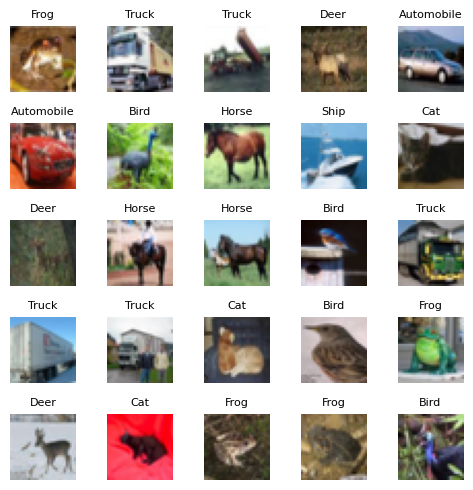

In [17]:
import numpy as np
import matplotlib.pyplot as plt

X_train = np.load(r"C:\Users\Hp\Desktop\cifar10-image-classificatio\artifacts\data_ingestion\X_train.npy")
y_train = np.load(r"C:\Users\Hp\Desktop\cifar10-image-classificatio\artifacts\data_ingestion\y_train.npy")

classes = [
    "Airplane", "Automobile", "Bird", "Cat", "Deer",
    "Dog", "Frog", "Horse", "Ship", "Truck"
]

plt.figure(figsize=(5, 5))

for i in range(25):
    plt.subplot(5, 5, i + 1)
    plt.imshow(X_train[i])
    plt.title(classes[y_train[i][0]], fontsize=8)
    plt.axis("off")

plt.tight_layout()
plt.show()